# UVMOS ETC Example With Inputted File (M Star Science Case 1)

_Written by Jocelyn Roney - July 2025 - Edited May 2026_

_With assistance from Dr. Tyrone Woods and Isaac Cheng_

This notebook will give an example on how to use CASTOR's UVMOS ETC when inputting a file, specifically synthetic UV M star quiescent  spectra. The Signal-to-Noise ratio is calculated using the inputted spectra.

Note: This notebook doesn't use the multi-slit function, only the spectrograph as it was created after this notebook.

The file I am using is from the HAZMAT program (The HAbitable Zones and M dwarf Activity across Time). The program uses GALEX data, HST COS, STIS spectra, and semi-empirical, full-wavelength models. The file is the '650 Myr 0.35M Median' taken from the Mikulski Archive for Space Telescopes found at this link -> https://archive.stsci.edu/hlsp/hazmat accessed in July 2025. This file was chosen as it most closely represents the M star EV Lac which CASTOR will observe once launched.  

Reference:
Schneider, A. C. and Shkolnik, E. L., “HAZMAT. III. The UV Evolution of Mid- to Late-M Stars with GALEX”, The Astronomical Journal, vol. 155, no. 3, Art. no. 122, IOP, 2018. doi:10.3847/1538-3881/aaaa24.

In [1]:
import matplotlib
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const

from castor_etc.background import Background
from castor_etc.photometry import Photometry
from castor_etc.sources import ExtendedSource, GalaxySource, PointSource
from castor_etc.telescope import Telescope

from castor_etc.uvmos_spectroscopy import UVMOS_Spectroscopy

import pandas as pd
import matplotlib.pyplot as plt
import math 

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## Step 1) Describe the telescope

First specify the telescope parameters by creating a `Telescope` object. All aspects of the telescope are customizable. For the UVMOS-ETC, you may wish to change the the full width at half-maximum of the telescope's point spread function, the pixel scale, the dark current, or the read noise.

Ex) To initialize a `Telescope` object with a specific dark current:

MyTelescope = Telescope( dark_current = 0.01 )

Ex) To change the dark current of an existing `Telescope` object:

MyTelescope.dark_current = 0.01 

In [2]:
MyTelescope = Telescope()
MyTelescope.dark_current = 0.02 
print('Mirror Area:  {:.3f}'.format( MyTelescope.mirror_area ))

print('Pixel Scale:  {:.3f}'.format( MyTelescope.px_scale ))

print('Pixel Area:  {:.3f}'.format( MyTelescope.px_area ))

print('Read Noise:   {:.3f}'.format( MyTelescope.read_noise ))

print('Dark Current  {:.3f}'.format( MyTelescope.dark_current ))

Mirror Area:  7853.982 cm2
Pixel Scale:  0.100 arcsec
Pixel Area:  0.010 arcsec2
Read Noise:   3.000
Dark Current  0.020


## Step 2) Characterize the background

By default, the `Background` object uses spectra from HST that give average Earthshine and zodiacal light values.

In [3]:
MyBackground = Background()

## Step 3) Read in the File

There are two ways that you can use your own data with the UVMOS.
1) `set_spectrum` requires you to load your data into two 1D arrays. The first array contains your wavelength data in Angstroms. The second array contains the flux data in erg/s/cm^2/A, erg/s/cm^2/Hz, AB magnitude, or ST magnitude. You must then specify which flux unit you chose with the key words listed in the function below. (I found it easiest to change my data into pandas dataframes then into two 1D arrays.)

   

2) `use_custom_spectrum` uses an ASCII or FITS file. Wavelength can be in any 'wavelength unit' u.AA for angstrom, u.nm for nanometer, u.um for micrometer etc. Flux is in flam (erg/s/cm^2/A).

In [4]:
'''
# If you are calling from Jupyter Notebook:
# You may need to remove arc/home/your_username and just have the file name.
#df = pd.read_csv("arc/home/your_username/file_name")


# Calling from Desktop:
# May need to change \ to /.
df = pd.read_csv(r"C:\Users\jgron\OneDrive\Desktop\CASTOR Summer 2025\Example Notbook 650Myr_Median\650Myr_0.35M_Median.csv")
print(df.head) #prints first few lines.


# Changing to array:
#For df to work the titles of your columns must match 'Wavelength (Ang)' and 'Flux Density (erg/cm2/s/Ang)'
#If this is not the case change the titles below to reflect your column titles.
#wavelength = df['Wavelength (Ang)'].to_numpy()
#flux = df['Flux Density (erg/cm2/s/Ang)'].to_numpy()


#######
#You may skip/comment out this section as my data had duplicate wavelengths which needed to be removed.

# Drop duplicates in 'Column1', keeping the first occurrence, this will also drop the attahced flux as well
df_no_duplicates = df.drop_duplicates(subset=['Wavelength (Ang)'], keep='first')
# Turns the two column df into two 1D arrays
wavelength = df_no_duplicates['Wavelength (Ang)'].to_numpy()
flux = df_no_duplicates['Flux Density (erg/cm2/s/Ang)'].to_numpy()

#######

'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 252-253: truncated \UXXXXXXXX escape (880543016.py, line 1)

In [5]:
# If you are calling from Jupyter Notebook:
# You may need to remove arc/home/your_username and just have the file name.
#df = pd.read_csv("arc/home/your_username/file_name")


# Calling from Desktop:
# You may need to change the \ to a /.
df = pd.read_csv("650Myr_0.35M_Median.csv")
print(df.head) #prints a few lines of your file to see if it worked.


# Changing to array:
#For df to work the titles of your columns must match 'Wavelength (Ang)' and 'Flux Density (erg/cm2/s/Ang)'
#If this is not the case change the titles below to reflect your column titles.
#wavelength = df['Wavelength (Ang)'].to_numpy()
#flux = df['Flux Density (erg/cm2/s/Ang)'].to_numpy()


###########################################################
#You may skip/comment out this section as my data had duplicate wavelengths which needed to be removed.

# Drop duplicates in 'Column1', keeping the first occurrence, this will also drop the attahced flux as well
df_no_duplicates = df.drop_duplicates(subset=['Wavelength (Ang)'], keep='first')
# Turns the two column df into two 1D arrays
wavelength = df_no_duplicates['Wavelength (Ang)'].to_numpy()
flux = df_no_duplicates['Flux Density (erg/cm2/s/Ang)'].to_numpy()

###########################################################

<bound method NDFrame.head of         Wavelength (Ang)  Flux Density (erg/cm2/s/Ang)
0                100.100                      0.259298
1                100.200                      0.112798
2                100.300                      0.109169
3                100.400                      0.070892
4                100.500                      0.932395
...                  ...                           ...
764141         54996.728                   4988.844900
764142         54997.030                   5081.594400
764143         54997.130                   5140.436500
764144         54999.000                   5984.116000
764145         54999.783                   5470.159600

[764146 rows x 2 columns]>


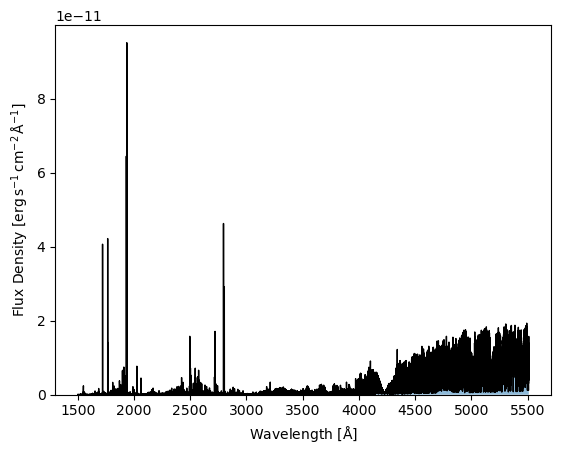

In [6]:
#To see full function with more details in the Castor Github go to ETC=> castor_etc=> spectrum.py
def set_spectrum(self, wavelengths, spectrum, unit, overwrite=False, quiet=False):
        """The input spectrum should have units of either flam (erg/s/cm^2/A), fnu
        (erg/s/cm^2/Hz), ABmag (AB magnitude), or STmag (ST magnitude). Note that the
        computed (and stored) spectrum will always be in units of flam.

        Parameters
        ----------
          wavelengths :: array of scalars or `astropy.Quantity` array
            The wavelengths over which to generate the uniform spectrum. If an array of
            scalars, it should be in angstrom. This should be a 1D array with the same
            length as the `spectrum` array.

          specturm :: array of scalars
            The value of the spectrum at the given wavelengths, in units of `unit`. This
            should be a 1D array with the same length as the `wavelengths` array.

          unit :: "flam" or "fnu" or "ABmag" or "STmag"
            The unit of the `spectrum` array: either flam (erg/s/cm^2/A), fnu
            (erg/s/cm^2/Hz), ABmag (AB magnitude), or STmag (ST magnitude).
        """
 

MySource = PointSource()
# My data had wavelength values from 0 Ang up to 55000 Ang. CASTORs bandwidth is from 1500 Ang to 5500 Ang. and the UVMOS is 1500 Ang to 3000 Ang.
# CASTOR will slice the file accordingly in 'Step 5) Do Spectroscopy'. 
# For visualization of my inputted file I sliced the wavlength range myself to see where the peaks are.
MySource.set_spectrum(wavelengths = wavelength[94866:595683], spectrum = flux[94866:595683], unit = "flam")

# The value put into 'MySource.norm_to_AB_mag()' to normalize the spectrum will drastically change the SNR times.
# Normalize a spectrum to a given AB magnitude in a specified passband or to a given bolometric AB magnitude.
# EV Lac has absolute bolometric magnitude Mbol = 8.7.
# Absolute Visual Magnitude M_V 11.7 and BC is -3 mag.



MySource.norm_to_AB_mag(8.7)

MySource.show_spectrum()

### Simulate the Source: Method 2)
This method requires your file be in ASCII or FITS file format.

In [7]:
#To see full function in the Castor Github go to ETC=> castor_etc=> spectrum.py
def use_custom_spectrum(
        self, filepath, wavelength_unit=u.AA, overwrite=False, quiet=False
    ):
        """
        Use custom spectrum from an ASCII or FITS file. 

        Parameters
        ----------
          filepath :: str
            The absolute path to the file containing the spectrum.
            If the file is in ASCII format, the first column should contain the
            wavelengths in `wavelength_units` and the second column containing the
            spectrum in flam (erg/s/cm^2/A); the columns should be separated by a constant
            number of spaces. Lines starting with a hash (#) will be ignored. The file
            extension must not be .fit or .fits.
            If the file is in FITS format, the first field (index 0) should contain the
            wavelengths in `wavelength_units` and the second field (index 1) should
            contain the spectrum in flam (erg/s/cm^2/A). The file extension must be .fit
            or .fits.

          wavelength_unit :: `astropy.Quantity` length unit
            The unit of the wavelengths in the file (e.g., u.AA for angstrom, u.nm for
            nanometer, u.um for micrometer, etc.)

        """
        

# file_path = "your_file_name.txt"
# MySource = PointSource()
# MySource.use_custom_spectrum(file_path, wavelengt_unit = u.AA, overwrite=False, quiet=False)
# MySource.norm_to_AB_mag(10)
# MySource.show_spectrum()

## Step 5) Do Spectroscopy

In [8]:
#Create Spectroscopy object
MySpec = UVMOS_Spectroscopy(MyTelescope, MySource, MyBackground)

By default, the spectral range is set to be 150nm to 300nm. This may be changed by setting `MySpec.min_wave` or `MySpec.max_wave` to some number with a wavelength unit in angstroms. 

For example:
```Python
MySpec.min_wave = (150 * u.nm).to(u.AA)
MySpec.max_wave = (300 * u.nm).to(u.AA)
```


In order to do slit spectroscopy, a slit must be chosen.
By default, a slit with a width of 0.214" and height of 1" is used. Change the slit width and / or height.

For example: 
```Python
MySpec.specify_slit(slit_width = 0.15 * u.arcsec, slit_height = 0.5 * u.arcsec   )
```

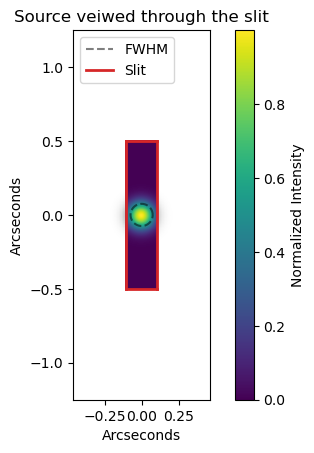

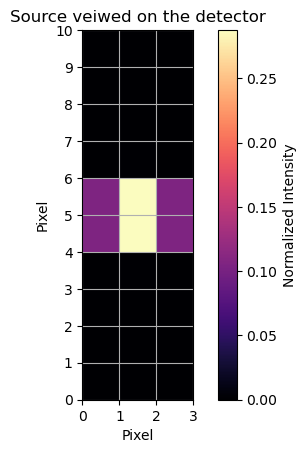

In [9]:
# Specify the slit
MySpec.specify_slit()

# Optional: Show the source as viewed through the slit
MySpec.show_slit()

# Optional: Show a single image of the slit on the detector
MySpec.show_source_pix_weights()

By default, the extraction box is set to a width of 1 pixel along the wavelength axis, and extends along the entire spatial axis. The extraction box may be changed by passing the desired values to calculate CASTOR spectra functions. 

For example:
```Python
MySpec.calc_source_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')
```

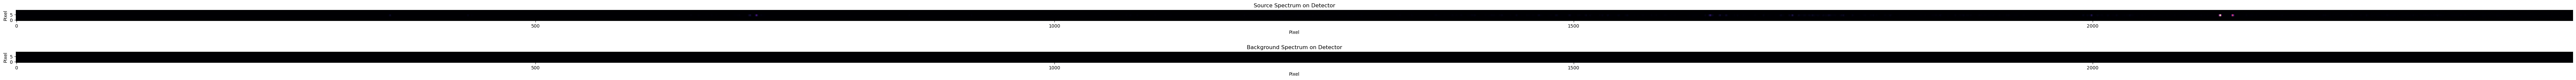

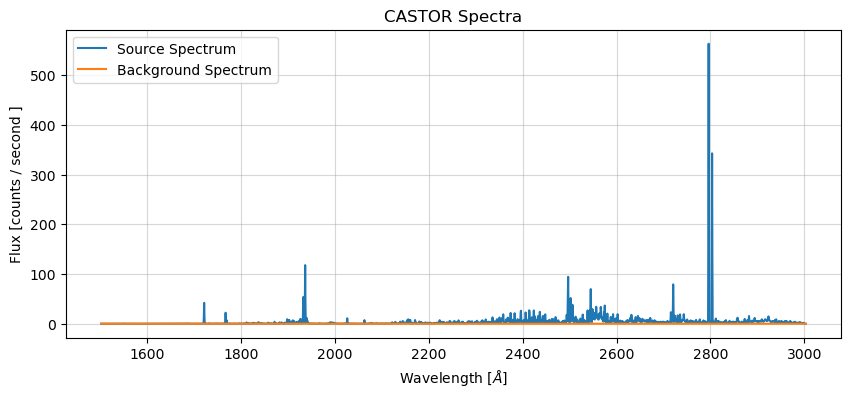

In [10]:
MySpec.calc_source_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')
MySpec.calc_background_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')


# Optional: Visualize the source and background spectra on the detector
plt.figure(figsize=(100,3))

ax1 = plt.subplot(211)
plt.imshow(MySpec.source_detector,origin='lower',cmap='magma',aspect='auto')
plt.title('Source Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax1.set_aspect('equal')


ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
plt.imshow(MySpec.background_detector*MySpec.source_extracted_numpixs,origin='lower',cmap='magma',aspect='auto', vmin=min(MySpec.source_detector.flatten()), vmax=max(MySpec.source_detector.flatten()))
plt.title('Background Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax2.set_aspect('equal')



# Optional: Visualize the source and background 
plt.figure(figsize=(10,4))
ax = plt.subplot(111)
plt.plot(MySpec.waves_CASTORSpectrum, MySpec.source_CASTORSpectrum,'-',label='Source Spectrum')

plt.plot(MySpec.waves_CASTORSpectrum, MySpec.background_CASTORSpectrum*MySpec.source_extracted_numpixs,'-',label='Background Spectrum')

plt.title('CASTOR Spectra')
plt.xlabel('Wavelength '+r'[$\AA$]')
plt.ylabel('Flux [counts / second ]')
plt.grid(alpha=0.5)
plt.legend()

#plt.savefig('650Myr_0.35M_Minimum.png')#To save your Castor spectrum

## Determine Exposure Time and Signal-to-Noise Ratio

When determining the SNR keep in mind the object you are looking at. For bright objects a low SNR of 3 or 5 is sufficient. This notebook is looking at synthetic M star quiescent data. M stars are dim and require a much larger SNR of 50-100. You also want to have some knowledge of what wavelength to look at. For M stars, Mg II k and h are the strong emmision lines seen in the UV so I have chosen them as my 'wave' value. If you choose a wave that is not present in the 'CASTOR Spectra' above you will have very poor SNR values.

**650 Myr 0.35 Solar Masses: Determine Exposure time for Mg II k or 2803.53 Angstrom**


In [11]:
t = 100 # seconds
wave = 2803.53 # angstroms
snr = MySpec.calc_snr_from_t(t, wave)
print('After an exposure time of {:.3f} seconds a SNR of {:.3f} is reached at a wavelength of {} angstroms'.format(t,snr, wave))

After an exposure time of 100.000 seconds a SNR of 59.945 is reached at a wavelength of 2803.53 angstroms


In [12]:
snr = 50  
wave = 2803.53 # angstroms
t = MySpec.calc_t_from_snr(snr, wave)
print('An exposure time of {:.3g} seconds or {:.3g} hours is required to reach a SNR of {:.3f} at a wavelength of {} angstroms'.format(t, t/3600, snr, wave))

An exposure time of 555 seconds or 0.154 hours is required to reach a SNR of 50.000 at a wavelength of 2803.53 angstroms


**650 Myr 0.35 Solar Masses: Determine Exposure time for Mg II h or 2796.35 Angstrom**

In [13]:
t = 100 # seconds
wave = 2796.35 # angstroms
snr = MySpec.calc_snr_from_t(t, wave)
print('After an exposure time of {:.3f} seconds a SNR of {:.3f} is reached at a wavelength of {} angstroms'.format(t,snr, wave))

After an exposure time of 100.000 seconds a SNR of 98.185 is reached at a wavelength of 2796.35 angstroms


In [14]:
snr = 50  
wave = 2796.35 # angstroms
t = MySpec.calc_t_from_snr(snr, wave)
print('An exposure time of {:.3g} seconds or {:.3g} hours is required to reach a SNR of {:.3f} at a wavelength of {} angstroms'.format(t, t/3600, snr, wave))

An exposure time of 88.3 seconds or 0.0245 hours is required to reach a SNR of 50.000 at a wavelength of 2796.35 angstroms


In this case Mg II h gave a better signal and would maximaze data obtained during observation.